# Code fine-tuning model

In [1]:
pip install trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 11.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 39.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
Note: you may need to restart the kernel to use updated pack

In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, BitsAndBytesConfig
from datasets import load_dataset
from peft import LoraConfig
from trl import SFTTrainer
from huggingface_hub  import login

MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"
OUTPUT_DIR = "/kaggle/working/llama_3B_LoRA"
HF_TOKEN= "" # fill your Huggingface access tokens here
CHECKPOINT_DIR = "" # This path is used to load the current checkpoint. If you dont have any checkpoints, just let it null.
login(HF_TOKEN)

In [4]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token   

# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_use_double_quant=True,
#     bnb_4bit_compute_dtype=torch.float16
# )

# Load model
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16,
    device_map="auto"
)
model.config.use_cache=False

print(model)

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((3072,), eps=1e-05)
    (

In [5]:
dataset = load_dataset("json", data_files={"train" : "", # Fill your training set here (training set is used in .jsonl file)
                                           "valid":""}) # Fill your validation set here (validation set is used in .jsonl file)


# print(dataset["train"][0])

def format_sample(sample):
    text = tokenizer.apply_chat_template(
        sample["messages"],
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text":text}

train_dataset = dataset["train"].map(format_sample, remove_columns="messages")
validation_dataset = dataset["valid"].map(format_sample, remove_columns="messages")

Generating train split: 0 examples [00:00, ? examples/s]

Generating valid split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/39656 [00:00<?, ? examples/s]

Map:   0%|          | 0/6944 [00:00<?, ? examples/s]

In [6]:
from pathlib import Path

def get_checkpoint(checkpoint_dir):
    checkpoint = list(Path(checkpoint_dir).glob("checkpoint-*"))
    if not checkpoint:
        return None
    checkpoint = sorted(checkpoint, key= lambda p: int(p.name.split("-")[-1]))
    return str(checkpoint[-1])

print("Check point:", get_checkpoint(CHECKPOINT_DIR))

Check point: /kaggle/input/datasets/nguyenkhoi0904/llama-3b-lora-epoch-3/checkpoint-14700


In [7]:
# LoRA config
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)


In [8]:
# Training args
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    num_train_epochs=4,

    logging_strategy="steps",
    # logging_steps=100,
    logging_first_step=True,

    eval_strategy ="steps", # no, steps, epoch
    eval_steps=700,

    save_strategy="best", # no, steps, epoch, best
    # save_steps=100,
    save_total_limit=2,

    fp16=True,
    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False
)

In [9]:
# Trainer
trainer = SFTTrainer(
    model= model,
    train_dataset=train_dataset,
    eval_dataset= validation_dataset,
    args=training_args,
    peft_config=peft_config,
)

Adding EOS to train dataset:   0%|          | 0/39656 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/39656 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/6944 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/6944 [00:00<?, ? examples/s]

In [10]:
checkpoint = get_checkpoint(CHECKPOINT_DIR)

if checkpoint is None:
    print("Không có checkpoint nên train từ đầu")
    trainer.train()
else:
    print(f"Train từ checkpoint: {checkpoint}")
    trainer.train(resume_from_checkpoint=checkpoint)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Train từ checkpoint: /kaggle/input/datasets/nguyenkhoi0904/llama-3b-lora-epoch-3/checkpoint-14700


Step,Training Loss,Validation Loss
15400,0.896689,1.048610
16100,0.861164,1.047977
16800,0.853690,1.041498
17500,0.830792,1.039223
18200,0.835919,1.033382
18900,0.841231,1.031368
19600,0.838913,1.029894


In [11]:
# Save adapter
trainer.save_model(OUTPUT_DIR)
trainer.save_state()
tokenizer.save_pretrained(OUTPUT_DIR)

print("Saved LoRA adapter to:", OUTPUT_DIR)

Saved LoRA adapter to: /kaggle/working/llama_3B_LoRA


In [12]:
import shutil
shutil.make_archive("llama_3B_LoRA", "zip", OUTPUT_DIR)

'/kaggle/working/llama_3B_LoRA.zip'

# Code đánh giá Llama sau khi fine-tune

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, BitsAndBytesConfig
from datasets import load_dataset
from peft import PeftModel
from huggingface_hub  import login
import re
import json

MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"
OUTPUT_DIR = "/kaggle/working/llama_model"
LORA_PATH = "" # use your LoRA path to load the LoRa weighted
TEST_PATH = "" # use your path to load the testset, the testset is used in the .jsonl file.
HF_TOKEN= "" # # Fill your Huggingface Access Tokens here
login(HF_TOKEN)

In [2]:
tokenizer = AutoTokenizer.from_pretrained(LORA_PATH, use_fast=False)
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16, device_map="auto")

model = PeftModel.from_pretrained(base_model, LORA_PATH) # load LoRA Adapter vào base model

model = model.merge_and_unload()
model.eval()

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((3072,), eps=1e-05)
    (

In [3]:
test_set = load_dataset("json",data_files= {"test":TEST_PATH})

Generating test split: 0 examples [00:00, ? examples/s]

In [4]:
import json
import re

def extract_scores(text):
    try:
        obj = json.loads(text)
        coh = int(obj["Coherence"])
        flu = int(obj["Fluency"])
        return coh, flu
    except:
        pass

    coh = re.search(r'"?Coherence"?\s*:\s*([1-5])', text)
    flu = re.search(r'"?Fluency"?\s*:\s*([1-5])', text)

    if coh and flu:
        return int(coh.group(1)), int(flu.group(1))
    return None, None

In [6]:
import json
n = len(test_set["test"])

true_value = []
pred_value = []

for i in range(n):
    sample = test_set["test"][i]
    prompt = [{"role":"system", "content":"Bạn là chuyên gia đánh giá chất lượng văn bản tiếng Việt theo 2 tiêu chí Coherence và Fluency, bạn hãy đánh giá chất lượng văn bản theo thang điểm từ 1 đến 5 và điểm càng cao càng tốt"},sample["messages"][0]]
    # if i <= 3:
    #     print(f"Sample: {sample}")
    #     print(f"Prompt: {prompt}")
    if i % 100 == 0:
        print(i)
    value = json.loads(sample["messages"][-1]["content"])
    true_value.append(value)

    prompt = tokenizer.apply_chat_template(
        prompt,
        tokenize=False,
        add_generation_prompt=True
    )
    # if i <= 3:
    #     print(prompt)
    # else:
    #     break
    inputs = tokenizer(prompt,
                      return_tensors="pt",
                      truncation=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=32,
            do_sample=True,
            pad_token_id = tokenizer.pad_token_id
        )
    decode = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated_text = decode[len(prompt):].strip() if decode.startswith(prompt) else decode.strip()
    if (i <= 3):
        print(f"{i}: {generated_text}")
    pred_coh, pred_flu = extract_scores(generated_text)
    pred_value.append({"Coherence": pred_coh, "Fluency":pred_flu})

0
0: system

Cutting Knowledge Date: December 2023
Today Date: 04 May 2026

Bạn là chuyên gia đánh giá chất lượng văn bản tiếng Việt theo 2 tiêu chí Coherence và Fluency, bạn hãy đánh giá chất lượng văn bản theo thang điểm từ 1 đến 5 và điểm càng cao càng tốtuser

Chương trình mục tiêu quốc gia phát triển kinh tế - xã hội vùng đồng bào dân tộc thiểu số và miền núi (DTTS&MN) giai đoạn 2021 - 2030, giai đoạn I từ năm 2021 đến năm 2025 được xem là một quyết sách đặc biệt trong việc thực hiện mục tiêu phát triển bền vững vùng đồng bào DTTS&MN. Thời điểm này, chương trình được triển khai thực hiện đã bước đầu phát huy tinh thần nỗ lực vươn lên của đồng bào DTTS...assistant

{"Coherence": 5, "Fluency": 4}
1: system

Cutting Knowledge Date: December 2023
Today Date: 04 May 2026

Bạn là chuyên gia đánh giá chất lượng văn bản tiếng Việt theo 2 tiêu chí Coherence và Fluency, bạn hãy đánh giá chất lượng văn bản theo thang điểm từ 1 đến 5 và điểm càng cao càng tốtuser

Giá tiêu hôm nay 16/10/2023 

In [7]:
if len(true_value) != len(pred_value):
    print(f"True list: {len(true_value)}")
    print(f"Pred list: {len(pred_value)}")
else:
    true_coh = []
    true_flu = []
    pred_coh = []
    pred_flu = []
    n = len(true_value)
    for i in range(n):
        true_coh.append(true_value[i]["Coherence"])
        true_flu.append(true_value[i]["Fluency"])
        pred_coh.append(pred_value[i]["Coherence"])
        pred_flu.append(pred_value[i]["Fluency"])

In [8]:
print(true_value[0])
print(pred_value[0])
print(type(pred_value[0]["Coherence"]))

{'Coherence': 5, 'Fluency': 5}
{'Coherence': 5, 'Fluency': 4}
<class 'int'>


In [9]:
print(len(true_flu))
print(len(pred_flu))

6964
6964


In [22]:
coh_t = {1:0, 2:0, 3:0, 4:0, 5:0}
coh_p = {1:0, 2:0, 3:0, 4:0, 5:0}
for i in range((len(true_coh))):
    coh_t[true_coh[i]] +=1
    coh_p[pred_coh[i]] +=1

print(coh_t)
print(coh_p)

{1: 1684, 2: 869, 3: 757, 4: 2065, 5: 1589}
{1: 1686, 2: 826, 3: 454, 4: 2280, 5: 1718}


In [10]:
#Accuracy
def accuracy_of_coherence_fluency(true_coh, true_flu, pred_cod, pred_flu):
    correct_coh = 0
    correct_flu = 0
    total_correct = 0
    n = len(true_coh)
    for i in range(n):
        if (true_coh[i] == pred_cod[i]):
            correct_coh+=1
        if (true_flu[i] == pred_flu[i]):
            correct_flu+=1
        if (true_coh[i] == pred_cod[i] and true_flu[i] == pred_flu[i]):
            total_correct+=1
    coh_accuracy = correct_coh / n
    flu_accuracy = correct_flu / n
    both_accuracy = total_correct / n
    return coh_accuracy, flu_accuracy, both_accuracy

coh_accuracy, flu_accuracy, both_accuracy = accuracy_of_coherence_fluency(true_coh, true_flu, pred_coh, pred_flu)
print(f"Coherence Accuracy: {coh_accuracy:.4f}")
print(f"Fluency Accuracy: {flu_accuracy:.4f}")
print(f"Both Accuracy: {both_accuracy:.4f}")

Coherence Accuracy: 0.5441
Fluency Accuracy: 0.5323
Both Accuracy: 0.4038


In [11]:
# MAE
from sklearn.metrics import mean_absolute_error
mae_coh = mean_absolute_error(true_coh, pred_coh)
mae_flu = mean_absolute_error(true_flu, pred_flu)
print(f"MAE Coherence: {mae_coh:.4f}")
print(f"MAE Fluency: {mae_flu:.4f}")

MAE Coherence: 0.5300
MAE Fluency: 0.5359


In [12]:
# Macro F1-score
from sklearn.metrics import f1_score
macro_f1_score_coh = f1_score(true_coh, pred_coh, average='macro')
macro_f1_score_flu = f1_score(true_flu, pred_flu, average='macro')
print(f"Macro F1-score Coherence: {macro_f1_score_coh:.4f}")
print(f"Macro F1-score Fluency: {macro_f1_score_flu:.4f}")

Macro F1-score Coherence: 0.5073
Macro F1-score Fluency: 0.5011


In [13]:
# Quadratic Weighted Kappa
from sklearn.metrics import cohen_kappa_score
qwk_coh = cohen_kappa_score(true_coh, pred_coh, weights="quadratic")
qwk_flu = cohen_kappa_score(true_flu, pred_flu, weights="quadratic")
print(f"QWK Coherence: {qwk_coh:.4f}")
print(f"QWK Fluency: {qwk_flu:.4f}")

QWK Coherence: 0.8574
QWK Fluency: 0.8577


In [14]:
print(f"Coherence Accuracy: {coh_accuracy:.4f}")
print(f"Fluency Accuracy: {flu_accuracy:.4f}")
print(f"Both Accuracy: {both_accuracy:.4f}")
print(f"MAE Coherence: {mae_coh:.4f}")
print(f"MAE Fluency: {mae_flu:.4f}")
print(f"Macro F1-score Coherence: {macro_f1_score_coh:.4f}")
print(f"Macro F1-score Fluency: {macro_f1_score_flu:.4f}")
print(f"QWK Coherence: {qwk_coh:.4f}")
print(f"QWK Fluency: {qwk_flu:.4f}")

Coherence Accuracy: 0.5441
Fluency Accuracy: 0.5323
Both Accuracy: 0.4038
MAE Coherence: 0.5300
MAE Fluency: 0.5359
Macro F1-score Coherence: 0.5073
Macro F1-score Fluency: 0.5011
QWK Coherence: 0.8574
QWK Fluency: 0.8577


In [15]:
with open("/kaggle/working/llama3-8B-accuracy.txt", "a") as f:
    f.write(f"Coherence Accuracy: {coh_accuracy:.4f}\n")
    f.write(f"Fluency Accuracy: {flu_accuracy:.4f}\n")
    f.write(f"Both Accuracy: {both_accuracy:.4f}\n")
    f.write(f"MAE Coherence: {mae_coh:.4f}\n")
    f.write(f"MAE Fluency: {mae_flu:.4f}\n")
    f.write(f"Macro F1-score Coherence: {macro_f1_score_coh:.4f}\n")
    f.write(f"Macro F1-score Fluency: {macro_f1_score_flu:.4f}\n")
    f.write(f"QWK Coherence: {qwk_coh:.4f}\n")
    f.write(f"QWK Fluency: {qwk_flu:.4f}\n")

# Đánh giá mô hình khi chưa fine-tune

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from huggingface_hub import login
import json

MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"
TEST_PATH = "" # use your path to load the testset, the testset is used in the .jsonl file.
HF_TOKEN = "" # Fill your Huggingface Access Tokens here
login(HF_TOKEN)

In [3]:
test_set = load_dataset("json", data_files={"test":TEST_PATH})

Generating test split: 0 examples [00:00, ? examples/s]

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16, device_map="auto")
model.eval()

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((3072,), eps=1e-05)
    (

In [5]:
import json
import re

def extract_scores(text):
    try:
        obj = json.loads(text)
        coh = int(obj["Coherence"])
        flu = int(obj["Fluency"])
        return coh, flu
    except:
        pass

    coh = re.search(r'"?Coherence"?\s*:\s*([1-5])', text)
    flu = re.search(r'"?Fluency"?\s*:\s*([1-5])', text)

    if coh and flu:
        return int(coh.group(1)), int(flu.group(1))
    return None, None

In [15]:
n = len(test_set["test"])
true_value = []
pred_value = []

for i in range(n):
    sample = test_set["test"][i]
    prompt = [{"role": "system", "content":'You are an expert in evaluating the quality of Vietnamese texts based on two criteria: Coherence and Fluency. You rate quality on a scale of 1 to 5, with higher scores being better. Then, return the results in JSON format as follows: {"Coherence":...,"Fluency":...}". No further explanation is required.'}, sample["messages"][0]]

    value = json.loads(sample["messages"][-1]["content"])
    true_value.append(value)
    if i % 100 == 0:
        print(i)

    prompt = tokenizer.apply_chat_template(
        prompt,
        tokenize=False,
        add_generation_prompt=True
    )
    # if i <=3 :
    #     print(f"Prompt: {prompt}")
    # else:
    #     break
    inputs = tokenizer(prompt,
                      return_tensors="pt",
                      truncation=True).to(model.device)
    with torch.no_grad():      
        outputs = model.generate(
            **inputs,
            max_new_tokens=32,
            do_sample=True,
            pad_token_id = tokenizer.eos_token_id
        )
    decode = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated_text = decode[len(prompt):].strip() if decode.startswith(prompt) else decode.strip()
    if (i <= 3):
        print(f"{i}: {generated_text}")
    # else:
    #     break
    pred_coh, pred_flu = extract_scores(generated_text)
    pred_value.append({"Coherence": pred_coh, "Fluency":pred_flu})

0
0: system

Cutting Knowledge Date: December 2023
Today Date: 06 May 2026

You are an expert in evaluating the quality of Vietnamese texts based on two criteria: Coherence and Fluency. You rate quality on a scale of 1 to 5, with higher scores being better. Then, return the results in JSON format as follows: {"Coherence":...,"Fluency":...}". No further explanation is required.user

Chương trình mục tiêu quốc gia phát triển kinh tế - xã hội vùng đồng bào dân tộc thiểu số và miền núi (DTTS&MN) giai đoạn 2021 - 2030, giai đoạn I từ năm 2021 đến năm 2025 được xem là một quyết sách đặc biệt trong việc thực hiện mục tiêu phát triển bền vững vùng đồng bào DTTS&MN. Thời điểm này, chương trình được triển khai thực hiện đã bước đầu phát huy tinh thần nỗ lực vươn lên của đồng bào DTTS...assistant

{"Coherence": 4,"Fluency": 5}
1: system

Cutting Knowledge Date: December 2023
Today Date: 06 May 2026

You are an expert in evaluating the quality of Vietnamese texts based on two criteria: Coherence a

In [24]:
if len(true_value) != len(pred_value):
    print(f"True list: {len(true_value)}")
    print(f"Pred list: {len(pred_value)}")
else:
    true_coh = []
    true_flu = []
    pred_coh = []
    pred_flu = []
    n = len(true_value)
    for i in range(n):
        if (pred_value[i]["Coherence"] is not None and pred_value[i]["Fluency"] is not None):
            true_coh.append(true_value[i]["Coherence"])
            true_flu.append(true_value[i]["Fluency"])
            pred_coh.append(pred_value[i]["Coherence"])
            pred_flu.append(pred_value[i]["Fluency"])

In [25]:
print(f"True list: {len(true_value)}")
print(f"Pred list: {len(pred_value)}")

True list: 6964
Pred list: 6964


In [17]:
print(true_value[0])
print(pred_value[0])
print(type(pred_value[0]["Coherence"]))

{'Coherence': 5, 'Fluency': 5}
{'Coherence': 4, 'Fluency': 5}
<class 'int'>


In [26]:
coh_t = {1:0, 2:0, 3:0, 4:0, 5:0}
coh_p = {1:0, 2:0, 3:0, 4:0, 5:0}
for i in range((len(true_coh))):
    coh_t[true_coh[i]] +=1
    coh_p[pred_coh[i]] +=1

print(coh_t)
print(coh_p)

{1: 1664, 2: 864, 3: 752, 4: 2060, 5: 1582}
{1: 0, 2: 252, 3: 1044, 4: 4353, 5: 1273}


In [27]:
#Accuracy
def accuracy_of_coherence_fluency(true_coh, true_flu, pred_cod, pred_flu):
    correct_coh = 0
    correct_flu = 0
    total_correct = 0
    n = len(true_coh)
    for i in range(n):
        if (true_coh[i] == pred_cod[i]):
            correct_coh+=1
        if (true_flu[i] == pred_flu[i]):
            correct_flu+=1
        if (true_coh[i] == pred_cod[i] and true_flu[i] == pred_flu[i]):
            total_correct+=1
    coh_accuracy = correct_coh / n
    flu_accuracy = correct_flu / n
    both_accuracy = total_correct / n
    return coh_accuracy, flu_accuracy, both_accuracy

coh_accuracy, flu_accuracy, both_accuracy = accuracy_of_coherence_fluency(true_coh, true_flu, pred_coh, pred_flu)
print(f"Coherence Accuracy: {coh_accuracy:.4f}")
print(f"Fluency Accuracy: {flu_accuracy:.4f}")
print(f"Both Accuracy: {both_accuracy:.4f}")

Coherence Accuracy: 0.2891
Fluency Accuracy: 0.2730
Both Accuracy: 0.0958


In [28]:
# MAE
from sklearn.metrics import mean_absolute_error
mae_coh = mean_absolute_error(true_coh, pred_coh)
mae_flu = mean_absolute_error(true_flu, pred_flu)
print(f"MAE Coherence: {mae_coh:.4f}")
print(f"MAE Fluency: {mae_flu:.4f}")

MAE Coherence: 1.1914
MAE Fluency: 1.2713


In [29]:
# Macro F1-score
from sklearn.metrics import f1_score
macro_f1_score_coh = f1_score(true_coh, pred_coh, average='macro')
macro_f1_score_flu = f1_score(true_flu, pred_flu, average='macro')
print(f"Macro F1-score Coherence: {macro_f1_score_coh:.4f}")
print(f"Macro F1-score Fluency: {macro_f1_score_flu:.4f}")

Macro F1-score Coherence: 0.1953
Macro F1-score Fluency: 0.1923


In [30]:
# Quadratic Weighted Kappa
from sklearn.metrics import cohen_kappa_score
qwk_coh = cohen_kappa_score(true_coh, pred_coh, weights="quadratic")
qwk_flu = cohen_kappa_score(true_flu, pred_flu, weights="quadratic")
print(f"QWK Coherence: {qwk_coh:.4f}")
print(f"QWK Fluency: {qwk_flu:.4f}")

QWK Coherence: 0.2799
QWK Fluency: 0.2831


In [31]:
print(f"Coherence Accuracy: {coh_accuracy:.4f}")
print(f"Fluency Accuracy: {flu_accuracy:.4f}")
print(f"Both Accuracy: {both_accuracy:.4f}")
print(f"MAE Coherence: {mae_coh:.4f}")
print(f"MAE Fluency: {mae_flu:.4f}")
print(f"Macro F1-score Coherence: {macro_f1_score_coh:.4f}")
print(f"Macro F1-score Fluency: {macro_f1_score_flu:.4f}")
print(f"QWK Coherence: {qwk_coh:.4f}")
print(f"QWK Fluency: {qwk_flu:.4f}")

Coherence Accuracy: 0.2891
Fluency Accuracy: 0.2730
Both Accuracy: 0.0958
MAE Coherence: 1.1914
MAE Fluency: 1.2713
Macro F1-score Coherence: 0.1953
Macro F1-score Fluency: 0.1923
QWK Coherence: 0.2799
QWK Fluency: 0.2831


In [33]:
with open("/kaggle/working/llama3-8B-non_fine_tune-accuracy.txt", "a") as f:
    f.write(f"Coherence Accuracy: {coh_accuracy:.4f}\n")
    f.write(f"Fluency Accuracy: {flu_accuracy:.4f}\n")
    f.write(f"Both Accuracy: {both_accuracy:.4f}\n")
    f.write(f"MAE Coherence: {mae_coh:.4f}\n")
    f.write(f"MAE Fluency: {mae_flu:.4f}\n")
    f.write(f"Macro F1-score Coherence: {macro_f1_score_coh:.4f}\n")
    f.write(f"Macro F1-score Fluency: {macro_f1_score_flu:.4f}\n")
    f.write(f"QWK Coherence: {qwk_coh:.4f}\n")
    f.write(f"QWK Fluency: {qwk_flu:.4f}\n")

# Code vẽ biểu đồ cho mô hình sau khi fine-tune

In [7]:
import json
import re
from matplotlib import pyplot as plt

TRAINER_STATE_PATH = "" # use your trainer state path to demonstrate your loss

In [22]:
with open(TRAINER_STATE_PATH, "r", encoding="utf-8") as f:
    trainer_state = json.load(f)
train_loss = []
train_steps = []
eval_loss = []
eval_steps = []

for i in range(len(trainer_state["log_history"])):
    try:
        loss = trainer_state["log_history"][i]["loss"]
        train_loss.append(loss)
        train_steps.append(trainer_state["log_history"][i]["step"])
        
    except:
        loss = trainer_state["log_history"][i]["eval_loss"]
        eval_loss.append(loss)
        eval_steps.append(trainer_state["log_history"][i]["step"])
print(len(train_loss))
print(len(eval_loss))

37
26


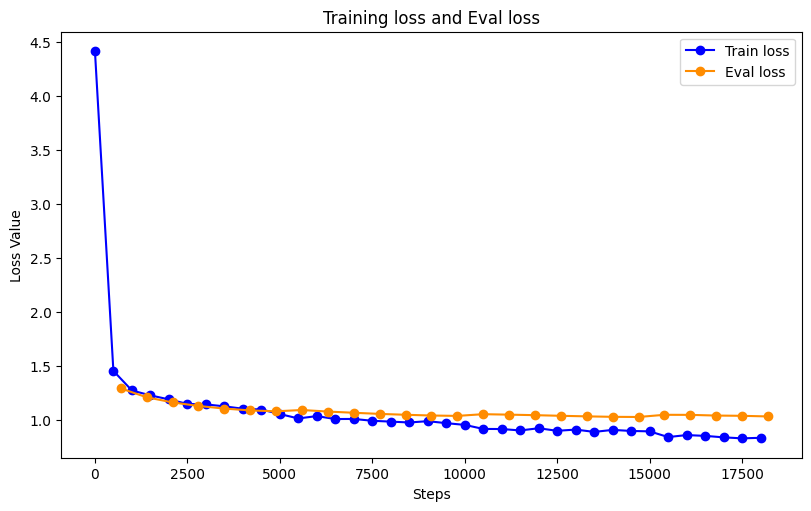

In [43]:
plt.figure(figsize=(8,5), layout="constrained")
plt.plot(train_steps, train_loss, label="Train loss", marker="o", color="b")
plt.plot(eval_steps, eval_loss, label="Eval loss", marker="o", color="#FF8C00")
plt.xlabel("Steps")
plt.ylabel("Loss Value")
plt.title("Training loss and Eval loss")
plt.legend()
plt.savefig(fname="Llama-3_2-3B-Instruct.png")
plt.show()

In [9]:
FINE_TUNED_ACCURACY_PATH = "" # this path is used to load the accuracy score from 4 metrics in .txt file
l = []
with open(FINE_TUNED_ACCURACY_PATH, "r", encoding="utf-8") as f:
    for line in f:
        l.append(json.loads(line))
print(l)
coh_accuracy = l[0]['Coherence Accuracy']
flu_accuracy = l[1]['Fluency Accuracy']
coh_mae = l[3]['MAE Coherence']
flu_mae = l[4]['MAE Fluency']
coh_macro_f1_score = l[5]['Macro F1-score Coherence']
flu_macro_f1_score = l[6]['Macro F1-score Fluency']
coh_qwk = l[7]['QWK Coherence']
flu_qwk = l[8]['QWK Fluency']

[{'Coherence Accuracy': 0.5925}, {'Fluency Accuracy': 0.5701}, {'Both Accuracy': 0.4479}, {'MAE Coherence': 0.465}, {'MAE Fluency': 0.4831}, {'Macro F1-score Coherence': 0.5689}, {'Macro F1-score Fluency': 0.5594}, {'QWK Coherence': 0.8717}, {'QWK Fluency': 0.867}]


0.5925


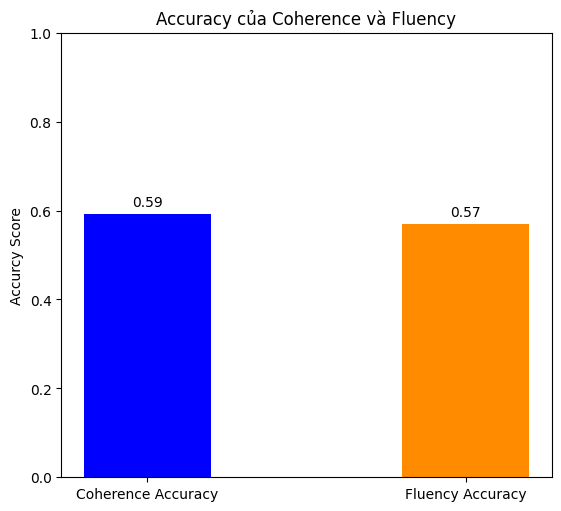

In [27]:
print(coh_accuracy)
plt.figure(figsize=(5.5,5), layout="constrained")
bars = plt.bar(["Coherence Accuracy", "Fluency Accuracy"], height=[coh_accuracy, flu_accuracy], width=0.4, color=["#0000FF","#FF8C00"])
plt.ylim((0, 1.0))
plt.bar_label(bars, padding=3, fmt='%.2f')
plt.ylabel("Accurcy Score")
plt.title("Accuracy của Coherence và Fluency")
plt.savefig("accuracy_coherence_fluency.png")
plt.show()

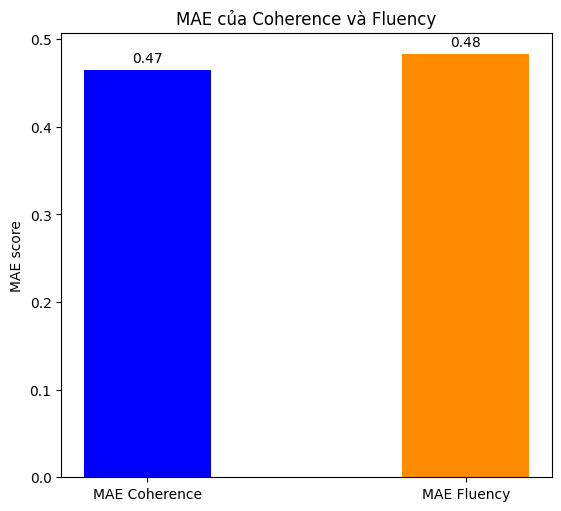

In [28]:
plt.figure(figsize=(5.5,5), layout="constrained")
bars = plt.bar(["MAE Coherence", "MAE Fluency"], height=[coh_mae,flu_mae], width=0.4, color=["#0000FF","#FF8C00"])
plt.ylabel("MAE score")
plt.bar_label(bars, padding=3, fmt="%.2f")
plt.title("MAE của Coherence và Fluency")
plt.savefig("mae_coherence_fluency.png")
plt.show()

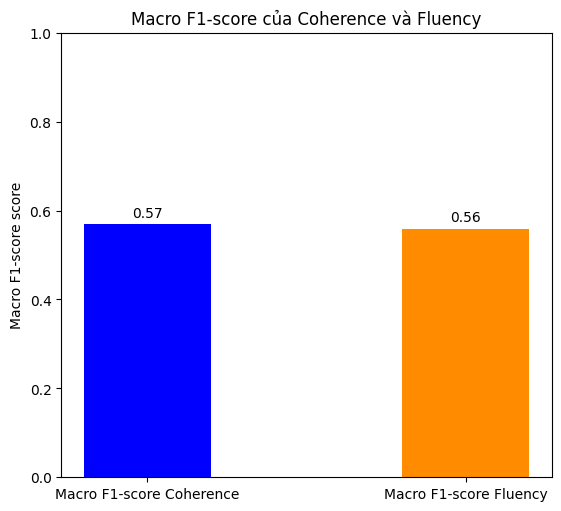

In [31]:
plt.figure(figsize=(5.5,5), layout="constrained")
bars = plt.bar(["Macro F1-score Coherence", "Macro F1-score Fluency"], height=[coh_macro_f1_score,flu_macro_f1_score], width=0.4, color=["#0000FF","#FF8C00"])
plt.ylim(0,1.0)
plt.ylabel("Macro F1-score score")
plt.bar_label(bars, padding=3, fmt="%.2f")
plt.title("Macro F1-score của Coherence và Fluency")
plt.savefig("macro_f1-score_coherence_fluency.png")
plt.show()

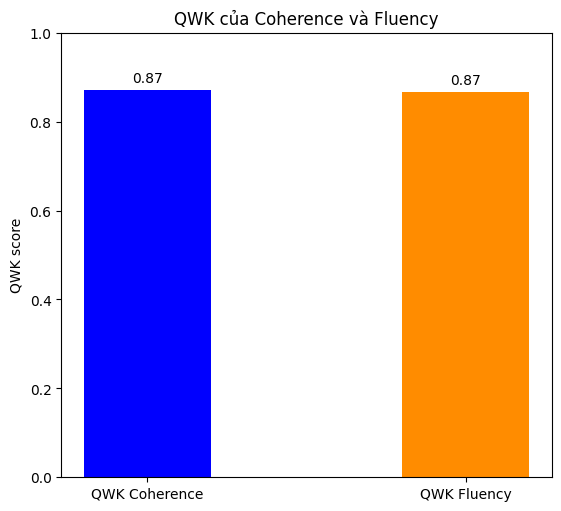

In [34]:
plt.figure(figsize=(5.5,5), layout="constrained")
bars = plt.bar(["QWK Coherence", "QWK Fluency"], height=[coh_qwk,flu_qwk], width=0.4, color=["#0000FF","#FF8C00"])
plt.ylim(0,1.0)
plt.ylabel("QWK score")
plt.bar_label(bars, padding=3, fmt="%.2f")
plt.title("QWK của Coherence và Fluency")
plt.savefig("qwk_coherence_fluency.png")
plt.show()